In [6]:
from IPython import display

%pip install pandas

display.clear_output()

In [7]:
import os
import pandas as pd

Check to see if state smoothing improves precision and recall over frame by frame detection. Ideally, state smoothing should lead to classification as open or closed being more accurate to the ground truth.

In [8]:
root = "/home/reuekennedy/Oyster-Video-Monitoring-System-2026/analysis/annotation_logs"

In [9]:
def getIOU(box1, box2):
  box1X1 = max(box1["x1"], 0)
  box1Y1 = max(box1["y1"], 0)
  box2X1 = max(box2["x1"], 0)
  box2Y1 = max(box2["y1"], 0)

  intersectionX1 = max(box1X1, box2X1)
  intersectionY1 = max(box1Y1, box2Y1)
  intersectionX2 = min(box1["x2"], box2["x2"])
  intersectionY2 = min(box1["y2"], box2["y2"])

  if ((intersectionX2 < intersectionX1) or (intersectionY2 < intersectionY1)):
    return 0

  intersectionArea = (intersectionX2 - intersectionX1) * (intersectionY2 - intersectionY1)

  box1Area = (box1["x2"] - box1X1) * (box1["y2"] - box1Y1)

  box2Area = (box2["x2"] - box2X1) * (box2["y2"] - box2Y1)

  unionArea = box1Area + box2Area - intersectionArea

  return intersectionArea / unionArea


In [10]:
true_positives_smooth = 0
true_positives_raw = 0
total_positives = 0
total_oysters = 0
detected_oysters = 0

for i in range(1,19):
    subdir = root + "/video_" + str(i)
    detections = pd.read_csv(subdir + "/oyster_video_" + str(i) + "_log.csv")
    frames = pd.read_csv(subdir + "/video_" + str(i) + "_frames.csv")
    ground_truth = subdir + "/truth"

    for subdirs, dirs, files in os.walk(ground_truth):
        frame_num = 0
        for file in files:
            if (file != ".DS_Store"):
                true_frame = pd.read_csv(ground_truth + "/" + file)
                total_oysters += len(true_frame)

                detected_frame = detections[detections["frame"] == frames.iloc[frame_num, 0]]
                total_positives += len(detected_frame)

                for idx, row in detected_frame.iterrows():
                    #use iou to find closest match
                    box1X1 = float(detected_frame.at[idx, "x1"])
                    box1Y1 = float(detected_frame.at[idx, "y1"])
                    box1X2 = float(detected_frame.at[idx, "x2"])
                    box1Y2 = float(detected_frame.at[idx, "y2"])
                    box1 = {"y1":box1Y1, "x1":box1X1, "y2":box1Y2, "x2":box1X2}
                    bestIOU = 0
                    match = -1

                    for idx2, row2 in true_frame.iterrows():
                        box2X1 = (float(true_frame.at[idx2, "xcenter"]) - true_frame.at[idx2, "width"] / 2) * 640
                        box2Y1 = (float(true_frame.at[idx2, "ycenter"]) - true_frame.at[idx2, "height"] / 2) * 640
                        box2X2 = (float(true_frame.at[idx2, "xcenter"]) + true_frame.at[idx2, "width"] / 2) * 640
                        box2Y2 = (float(true_frame.at[idx2, "ycenter"]) + true_frame.at[idx2, "height"] / 2) * 640
                        box2 = {"y1":box2Y1, "x1":box2X1, "y2":box2Y2, "x2":box2X2}
                        iou = getIOU(box1, box2)

                        if iou > bestIOU:
                            bestIOU = iou
                            match = idx2

                    #check if detection is a true positive
                    if bestIOU >= 0.3 and match != -1:
                        detected_oysters += 1
                        if ((detected_frame.at[idx, "smoothedLabel"] == "Oyster-Closed" and true_frame.at[match, "class"] == 0) or
                           (detected_frame.at[idx, "smoothedLabel"] == "Oyster-Open" and true_frame.at[match, "class"] == 1)):
                            true_positives_smooth += 1
                        if ((detected_frame.at[idx, "rawLabel"] == "Oyster-Closed" and true_frame.at[match, "class"] == 0) or
                              (detected_frame.at[idx, "rawLabel"] == "Oyster-Open" and true_frame.at[match, "class"] == 1)):
                            true_positives_raw += 1
                frame_num += 1

print(f"detected oysters: {detected_oysters}\n")
print(f"true positives smooth: {true_positives_smooth}")
print(f"correctly classified detections: {true_positives_smooth/detected_oysters}")
print(f"precision smooth: {true_positives_smooth/total_positives}")
print(f"recall smooth: {true_positives_smooth/total_oysters}\n")
print(f"true positives raw: {true_positives_raw}")
print(f"correctly classified detections: {true_positives_raw/detected_oysters}")
print(f"precision raw: {true_positives_raw/total_positives}")
print(f"recall raw: {true_positives_raw/total_oysters}")

detected oysters: 6265

true positives smooth: 4956
correctly classified detections: 0.7910614525139665
precision smooth: 0.243239263803681
recall smooth: 0.1911373365729492

true positives raw: 4923
correctly classified detections: 0.7857940941739825
precision raw: 0.2416196319018405
recall raw: 0.18986463033668866


Smoothed class label appear to more frequently match the ground truth than raw, frame-only labels. 

Note: Performance will be worse than model testing metrics since detection is only done once every 10 frames in the browser, leading to boxes not always aligning well with ground truth annotations. Additionally, ground truth annotations were done at 30 frames per second while videos are run at much higher fps in browser.

Check to see how confirmed counts and per frame counts compare to ground truth count. Ideally, confirmed count should fluctuate less, and average should more closely match ground truth.

Note: First two frames will be discounted to allow time for oysters to be confirmed and determine the initial confirmed total.

In [66]:
per_frame_1 = [2, 3, 1, 1, 7, 8, 1, 2, 3, 2, 4, 6, 6, 6, 9, 12]
confirmed_1 = [0, 0, 0, 1, 4, 4, 4, 5, 5, 5, 7, 8, 8, 9, 10, 11]

per_frame_2 = [8, 9, 10, 11, 11, 11, 8, 8, 7, 11, 5, 5, 9, 10]
confirmed_2 = [2, 6, 9, 12, 12, 13, 13, 14, 14, 15, 15, 15, 16, 16]

per_frame_3 = [10, 9, 9, 9, 10, 10, 9, 8, 10, 10]
confirmed_3 = [8, 9, 9, 9, 10, 10, 10, 10, 10, 10]

per_frame_4 = [13, 13, 14, 14, 14, 16, 16, 16, 16, 15, 15, 15, 17, 15, 15, 15, 17, 17, 16]
confirmed_4 = [12, 12, 13, 13, 13, 13, 15, 15, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17]

per_frame_5 = [12, 13, 12, 13, 12, 13, 14, 10, 13, 11]
confirmed_5 = [10, 11, 12, 12, 12, 13, 14, 14, 15, 15]

per_frame_6 = [12, 13, 14, 12, 14, 14, 13, 13, 13, 12, 12, 11, 11, 12, 12, 10, 11, 13, 12, 13, 13, 14, 14, 14, 13, 12, 11, 10, 8, 9, 8, 9, 11, 10, 10, 11, 11, 10, 11, 11, 9, 11, 13, 9, 9, 11, 10, 12, 12, 10, 10, 11, 10, 12, 10, 10, 10, 10, 10, 10, 9, 10, 10, 9, 10, 10, 10, 8]
confirmed_6 = [8, 11, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 14, 14, 14, 14, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 13, 13, 13, 13, 13, 13, 12, 12, 12, 12, 12, 12, 12]

per_frame_7 = [6, 8, 9, 8, 7, 9, 8, 8, 9, 9, 9, 9, 12, 8]
confirmed_7 = [5, 6, 8, 8, 8, 9, 9, 10, 10, 11, 11, 11, 11, 11]

per_frame_8 = [12, 11, 13, 11, 11, 12, 13, 11, 12, 13, 12, 12, 12, 12]
confirmed_8 = [8, 11, 11, 11, 11, 11, 12, 13, 14, 15, 15, 15, 16, 16]

per_frame_9 = [20, 18, 17, 20, 20, 20, 18, 16, 18, 17, 17, 15, 15, 16, 14, 16, 14, 14, 15, 14, 15, 14, 17, 18, 18, 18, 18, 18, 17, 15, 18, 15, 16, 17, 15]
confirmed_9 = [20, 20, 20, 20, 20, 21, 21, 21, 21, 22, 23, 23, 23, 23, 23, 23, 22, 22, 22, 22, 22, 21, 20, 20, 20, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20]

per_frame_10 = [33, 33, 33, 34, 32, 32, 33, 32, 34, 32, 33, 33, 34, 34, 34, 34, 34, 33, 33, 33, 33, 33, 33, 33, 34]
confirmed_10 = [33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34]

per_frame_11 = [6, 6, 5, 5, 5, 6, 5, 5, 6, 6, 5, 6, 7, 9, 10, 11, 9, 10, 9]
confirmed_11 = [4, 4, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 9, 9, 9, 11, 11, 11, 11]

per_frame_12 = [3, 3, 3, 5, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 4, 4, 4, 4, 4, 4, 4, 5, 4, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 3, 4, 3, 5, 4, 3, 4, 3, 4, 3, 3, 4, 3]
confirmed_12 = [3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

per_frame_13 = [8, 12, 9, 8, 9, 7, 8, 10, 11, 14, 16, 20]
confirmed_13 = [5, 6, 7, 8, 8, 8, 9, 10, 11, 13, 14, 19]

per_frame_14 = [25, 25, 26, 27, 28, 25, 26, 27, 27, 25, 25, 28, 29]
confirmed_14 = [21, 23, 24, 24, 25, 27, 28, 29, 29, 30, 30, 31, 33]

per_frame_15 = [12, 15, 13, 18, 20, 16, 15, 18, 17, 19, 19, 22, 21, 19, 22, 25, 25]
confirmed_15 = [11, 11, 12, 13, 14, 15, 18, 19, 20, 21, 21, 24, 24, 26, 27, 28, 30]

per_frame_16 = [0, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 0]
confirmed_16 = [0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 0]

per_frame_17 = [1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2]
confirmed_17 = [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

per_frame_18 = [0]
confirmed_18 = [0]

totals = [30, 20, 12, 21, 22, 11, 17, 13, 17, 28, 17, 5, 39, 32, 29, 2, 2, 2]

In [68]:
per_frame_counts = [per_frame_1, per_frame_2, per_frame_3, per_frame_4, per_frame_5, per_frame_6, per_frame_7, per_frame_8, per_frame_9, per_frame_10, per_frame_11, per_frame_12, per_frame_13, per_frame_14, per_frame_15, per_frame_16, per_frame_17, per_frame_18]
confirmed_counts = [confirmed_1, confirmed_2, confirmed_3, confirmed_4, confirmed_5, confirmed_6, confirmed_7, confirmed_8, confirmed_9, confirmed_10, confirmed_11, confirmed_12, confirmed_13, confirmed_14, confirmed_15, confirmed_16, confirmed_17, confirmed_18]
per_frame_avg = []
confirmed_avg = []

In [69]:
import statistics

In [70]:
for i in range (0, 18):
    per_frame_avg.append(statistics.mean(per_frame_counts[i]))
    confirmed_avg.append(statistics.mean(confirmed_counts[i]))

In [71]:
overall_total = 0
overall_per_frame = 0
overall_confirmed = 0
closer = 0

for i in range(0, 18):
    print(f"video {i + 1} | true total: {totals[i]} | per frame avg: {per_frame_avg[i]} | confirmed avg: {confirmed_avg[i]}")
    overall_total += totals[i]
    overall_confirmed += confirmed_avg[i]
    overall_per_frame += per_frame_avg[i]
    if abs(totals[i] - per_frame_avg[i]) > abs(totals[i] - confirmed_avg[i]):
        closer += 1

print(f"overall | true total: {overall_total} | per frame avg: {overall_per_frame} | confirmed avg: {overall_confirmed}")
print(f"confirmed avg was closer to true total in {closer/18}% of videos")

video 1 | true total: 30 | per frame avg: 4.5625 | confirmed avg: 5.0625
video 2 | true total: 20 | per frame avg: 8.785714285714286 | confirmed avg: 12.285714285714286
video 3 | true total: 12 | per frame avg: 9.4 | confirmed avg: 9.5
video 4 | true total: 21 | per frame avg: 15.210526315789474 | confirmed avg: 15.105263157894736
video 5 | true total: 22 | per frame avg: 12.3 | confirmed avg: 12.8
video 6 | true total: 11 | per frame avg: 11.058823529411764 | confirmed avg: 14.029411764705882
video 7 | true total: 17 | per frame avg: 8.5 | confirmed avg: 9.142857142857142
video 8 | true total: 13 | per frame avg: 11.928571428571429 | confirmed avg: 12.785714285714286
video 9 | true total: 17 | per frame avg: 16.65714285714286 | confirmed avg: 20.914285714285715
video 10 | true total: 28 | per frame avg: 33.16 | confirmed avg: 33.48
video 11 | true total: 17 | per frame avg: 6.894736842105263 | confirmed avg: 7.842105263157895
video 12 | true total: 5 | per frame avg: 3.983870967741935

In [72]:
import matplotlib.pyplot as plt

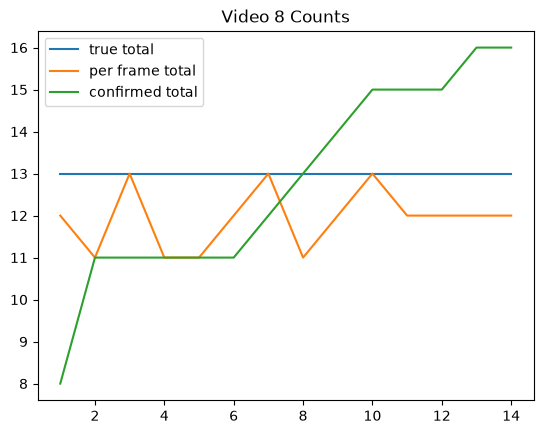

In [73]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
y = [13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13]

plt.plot(x, y, label="true total")
plt.plot(x, per_frame_8, label="per frame total")
plt.plot(x, confirmed_8, label="confirmed total")
plt.legend()
plt.title("Video 8 Counts")

plt.show()

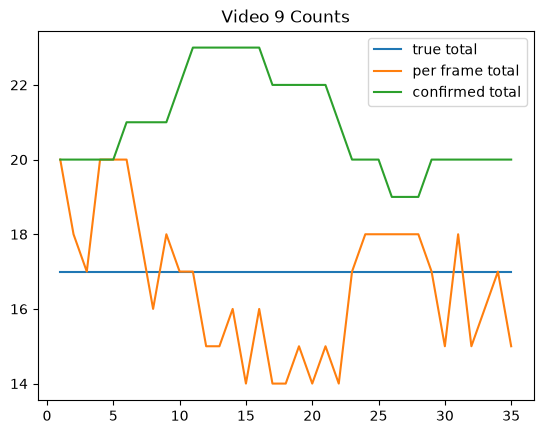

In [74]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
y = [17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17]

plt.plot(x, y, label="true total")
plt.plot(x, per_frame_9, label="per frame total")
plt.plot(x, confirmed_9, label="confirmed total")
plt.legend()
plt.title("Video 9 Counts")

plt.show()

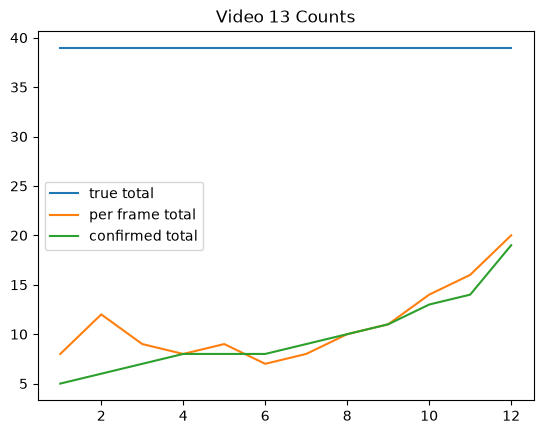

In [75]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
y = [39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39]

plt.plot(x, y, label="true total")
plt.plot(x, per_frame_13, label="per frame total")
plt.plot(x, confirmed_13, label="confirmed total")
plt.legend()
plt.title("Video 13 Counts")

plt.show()

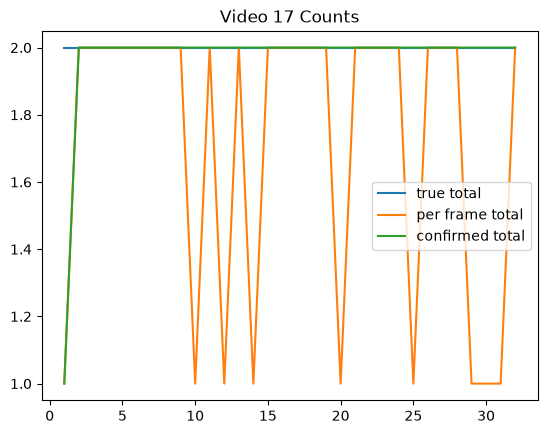

In [76]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
y = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

plt.plot(x, y, label="true total")
plt.plot(x, per_frame_17, label="per frame total")
plt.plot(x, confirmed_17, label="confirmed total")
plt.legend()
plt.title("Video 17 Counts")

plt.show()

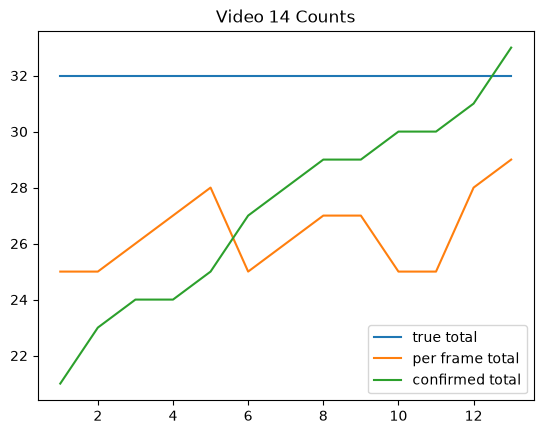

In [77]:
x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
y = [32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32]

plt.plot(x, y, label="true total")
plt.plot(x, per_frame_14, label="per frame total")
plt.plot(x, confirmed_14, label="confirmed total")
plt.legend()
plt.title("Video 14 Counts")

plt.show()